In [3]:
from profiling_and_attack import mlp_eshard, information, cnn, cnn_ASCAD, mlp

from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

In [3]:
import numpy as np

# Define the first and second arrays as NumPy arrays
array1 = np.array([
    [0, 0, 28, 0, 0, 0, 0, 0, 0],
    [0, 56, 0, 168, 0, 0, 0, 0, 0],
    [28, 0, 336, 0, 420, 0, 0, 0, 0],
    [0, 168, 0, 840, 0, 560, 0, 0, 0],
    [0, 0, 420, 0, 1120, 0, 420, 0, 0],
    [0, 0, 0, 560, 0, 840, 0, 168, 0],
    [0, 0, 0, 0, 420, 0, 336, 0, 28],
    [0, 0, 0, 0, 0, 168, 0, 56, 0],
    [0, 0, 0, 0, 0, 0, 28, 0, 0]
])[::-1]

array2 = np.array([
    [0, 0, 0, 56, 0, 0, 0, 0, 0],
    [0, 0, 168, 0, 280, 0, 0, 0, 0],
    [0, 168, 0, 840, 0, 560, 0, 0, 0],
    [56, 0, 840, 0, 1680, 0, 560, 0, 0],
    [0, 280, 0, 1680, 0, 1680, 0, 280, 0],
    [0, 0, 560, 0, 1680, 0, 840, 0, 56],
    [0, 0, 0, 560, 0, 840, 0, 168, 0],
    [0, 0, 0, 0, 280, 0, 168, 0, 0],
    [0, 0, 0, 0, 0, 56, 0, 0, 0]
])[::-1]

# Initialize an empty list to store the combined result
combined_array = []

# Loop through the arrays and combine them
for i in range(array1.shape[0]):
    row = []
    for j in range(array1.shape[1]):
        if array2[i, j] > 0:
            # Replace 0 in array1 with corresponding value from array2 and mark it in red
            row.append(f"\\textcolor{{red}}{{{array2[i, j]}}}")
        else:
            # Keep the non-zero value from array1
            row.append(str(array1[i, j]))
    combined_array.append(row)
# Convert the result into a LaTeX-friendly format
latex_result = "\\begin{bNiceArray}[columns-width=0.2em]{ccccccccc}\n"
for row in combined_array:
    latex_result += " & ".join(row) + " \\\\\n"
latex_result += "\\end{bNiceArray}"

# Print the LaTeX code
print(latex_result)

\begin{bNiceArray}[columns-width=0.2em]{ccccccccc}
0 & 0 & 0 & 0 & 0 & \textcolor{red}{56} & 28 & 0 & 0 \\
0 & 0 & 0 & 0 & \textcolor{red}{280} & 168 & \textcolor{red}{168} & 56 & 0 \\
0 & 0 & 0 & \textcolor{red}{560} & 420 & \textcolor{red}{840} & 336 & \textcolor{red}{168} & 28 \\
0 & 0 & \textcolor{red}{560} & 560 & \textcolor{red}{1680} & 840 & \textcolor{red}{840} & 168 & \textcolor{red}{56} \\
0 & \textcolor{red}{280} & 420 & \textcolor{red}{1680} & 1120 & \textcolor{red}{1680} & 420 & \textcolor{red}{280} & 0 \\
\textcolor{red}{56} & 168 & \textcolor{red}{840} & 840 & \textcolor{red}{1680} & 560 & \textcolor{red}{560} & 0 & 0 \\
28 & \textcolor{red}{168} & 336 & \textcolor{red}{840} & 420 & \textcolor{red}{560} & 0 & 0 & 0 \\
0 & 56 & \textcolor{red}{168} & 168 & \textcolor{red}{280} & 0 & 0 & 0 & 0 \\
0 & 0 & 28 & \textcolor{red}{56} & 0 & 0 & 0 & 0 & 0 \\
\end{bNiceArray}


In [4]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=400)

    return model
def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result

In [6]:
dataset_id = 'ches_ctf'
resample_window=80
traces_dim = 15000
model = mlp_eshard(9,traces_dim)
n_prof= 30000




lm = "HW"
target_byte = 2
path = "/mnt/d/Datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)
pi_og, pi_patch_new, pi_patch_og = [], [], []
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 15000)]           0         
                                                                 
 dense (Dense)               (None, 40)                600040    
                                                                 
 dense_1 (Dense)             (None, 40)                1640      
                                                                 
 dense_2 (Dense)             (None, 40)                1640      
                                                                 
 dense_3 (Dense)             (None, 40)                1640      
                                                                 
 output (Dense)              (None, 9)                 369       
                                                                 
Total params: 605329 (2.31 MB)
Trainable params: 605329

2025-01-31 09:32:15.226328: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-31 09:32:15.243892: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-31 09:32:15.243934: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-31 09:32:15.246820: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-31 09:32:15.246864: I external/local_xla/xla/stream_executor

In [7]:
def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    layer = layers
    model.load_weights(f"model_checkpoints/mlp_ches_ctf_{epoch:02d}.weights.h5")
    outputs = [model.layers[layer].output for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()
sbox_ins = (dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))
probes_for_bit = []

def only_reload(epoch):
    model.load_weights(f"model_checkpoints/mlp_ches_ctf_{epoch:02d}.weights.h5")

layer_out = 4
def retrain_probes_per_bit():

    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[layer_out],(dataset.profiling_labels.astype(np.uint8)>>k)&0x1, epochs=5)
        probes_for_bit.append(probe_for_sbox_input)

    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[layer_out],(sbox_ins>>k)&0x1, epochs=5)
        probes_for_bit.append(probe_for_sbox_input)

In [6]:
reload_model(45)

#reload_model(199)
#retrain_probes_per_bit()

  8/938 [..............................] - ETA: 9s  

2025-01-25 17:12:43.840010: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


313/313 [==============================] - 1s 2ms/step


 46/157 [=======>......................] - ETA: 0s

2025-01-26 09:54:57.646507: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


157/157 [==============================] - 0s 2ms/step


1 -0.11441026398715351 -0.11508607666021636
157/157 [==============================] - 0s 1ms/step


2 -0.016092606516449736 -0.18651369964605652
157/157 [==============================] - 0s 1ms/step


...

195 1.0319719869894097 0.9340436001586313
157/157 [==============================] - 0s 2ms/step


196 1.0032227331441952 0.9696359204100955
157/157 [==============================] - 0s 1ms/step


197 1.1123713918966363 1.024423257141053
157/157 [==============================] - 0s 2ms/step


198 1.0921095861715384 1.020214942626893
157/157 [==============================] - 0s 1ms/step


199 1.1047179449361872 1.0232777615355841
157/157 [==============================] - 0s 1ms/step
200 0.943670526723296 0.761436759643494


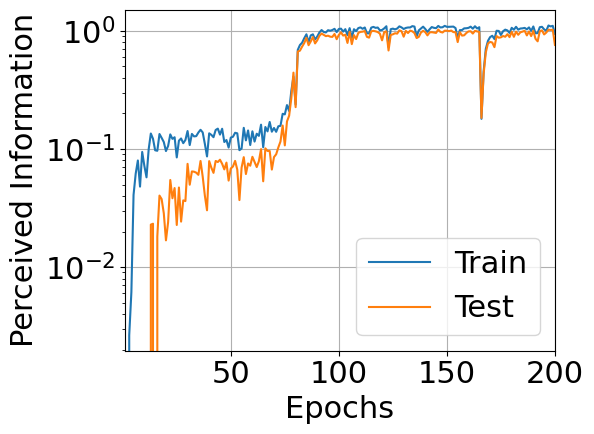

In [12]:
import gc
import matplotlib
pi_list  = []
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
pi_prof = []
# print(len(pi_list))
#for i in range(len(pi_list), 201):
for i in range(1, 201):
    only_reload(i)
    pi = information(model.predict(dataset.x_attack[:5000]), dataset.attack_labels[:5000], 9)
    pi_list.append(pi)

    pi = information(model.predict(dataset.x_profiling[:5000]), dataset.profiling_labels[:5000], 9)
    pi_prof.append(pi)
    gc.collect(2)
    print(i, pi, pi_list[-1])

font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}

plt.plot(range(1, 201), pi_prof, label="Train")
plt.plot(range(1, 201), pi_list, label="Test")

plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Perceived Information")
plt.xlim([1, 200])
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("PI_ches.png", dpi=200)
plt.show()


In [8]:
reload_model(100)

from sklearn.decomposition import PCA
layer=1
new_model_for_probe = Model(model.layers[layer+1].input, model.output)
comp_n = 3
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
new_pca = PCA(n_components=comp_n)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
in_neurons = tf.Variable(tmp_att[layer])

inf_scores = np.zeros((100, comp_n))
for i in [0]:
    with tf.GradientTape() as tape:
        #inter = new_pca.inverse_transform(in_neurons)
        predicts = new_model_for_probe(in_neurons, training=False)
        
        #[:, 1] #+ probes_for_bit[i+1](inter, training=False)[:, 0]
        loss = tf.keras.losses.CategoricalCrossentropy()( predicts, dataset.y_attack)
                
        # predicts =  probes_for_bit[i](inter, training=True)#[:, 1] #+ probes_for_bit[i+1](inter, training=False)[:, 0]
        # loss = tf.keras.losses.CategoricalCrossentropy()( predicts, tf.keras.utils.to_categorical((dataset.attack_labels>>i)&0x1))

    grads = tape.gradient(loss, in_neurons)
    dgrad_abs = tf.math.abs(grads)

    inf_score = np.average(dgrad_abs.numpy(), axis=0)
    #inf_scores[i] = inf_score
    #print(inf_score)
    
    plt.plot(inf_score, label=f"Bit{i}")
# plt.plot(bit_on_sum)
# plt.plot(bit_off_sum)
plt.legend()
plt.show()

NameError: name 'tmp' is not defined

In [6]:

#reload_model(199)
epoch=100
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
#reload_model(epoch)
comp_n= 3
new_pca = PCA(n_components=comp_n)
layer=1
#imp_neurons = np.where(inf_score > np.mean(inf_score))[0]
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])


in1 = 2
in2 = 1
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
#plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
for i in range(0, 2):
    on = np.where(dataset.attack_labels %2 == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="Even" if i == 0 else "Odd", alpha=0.5)
    #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label="Even HW" if i == 0 else "Odd HW", alpha=0.5)

# plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 1], label="KMEANs")
# #plt.scatter(initialize_arr[:, 2], initialize_arr[:, 1], label="INIT")
# plt.plot(kmeans.cluster_centers_[sorted_points, 2], kmeans.cluster_centers_[sorted_points, 1])
plt.grid()
plt.legend(loc=1)

plt.savefig(f"even_odd_epoch_{epoch}.png", dpi=200)
plt.show()
plt.close()


NameError: name 'tmp' is not defined

313/313 [==============================] - 0s 1ms/step


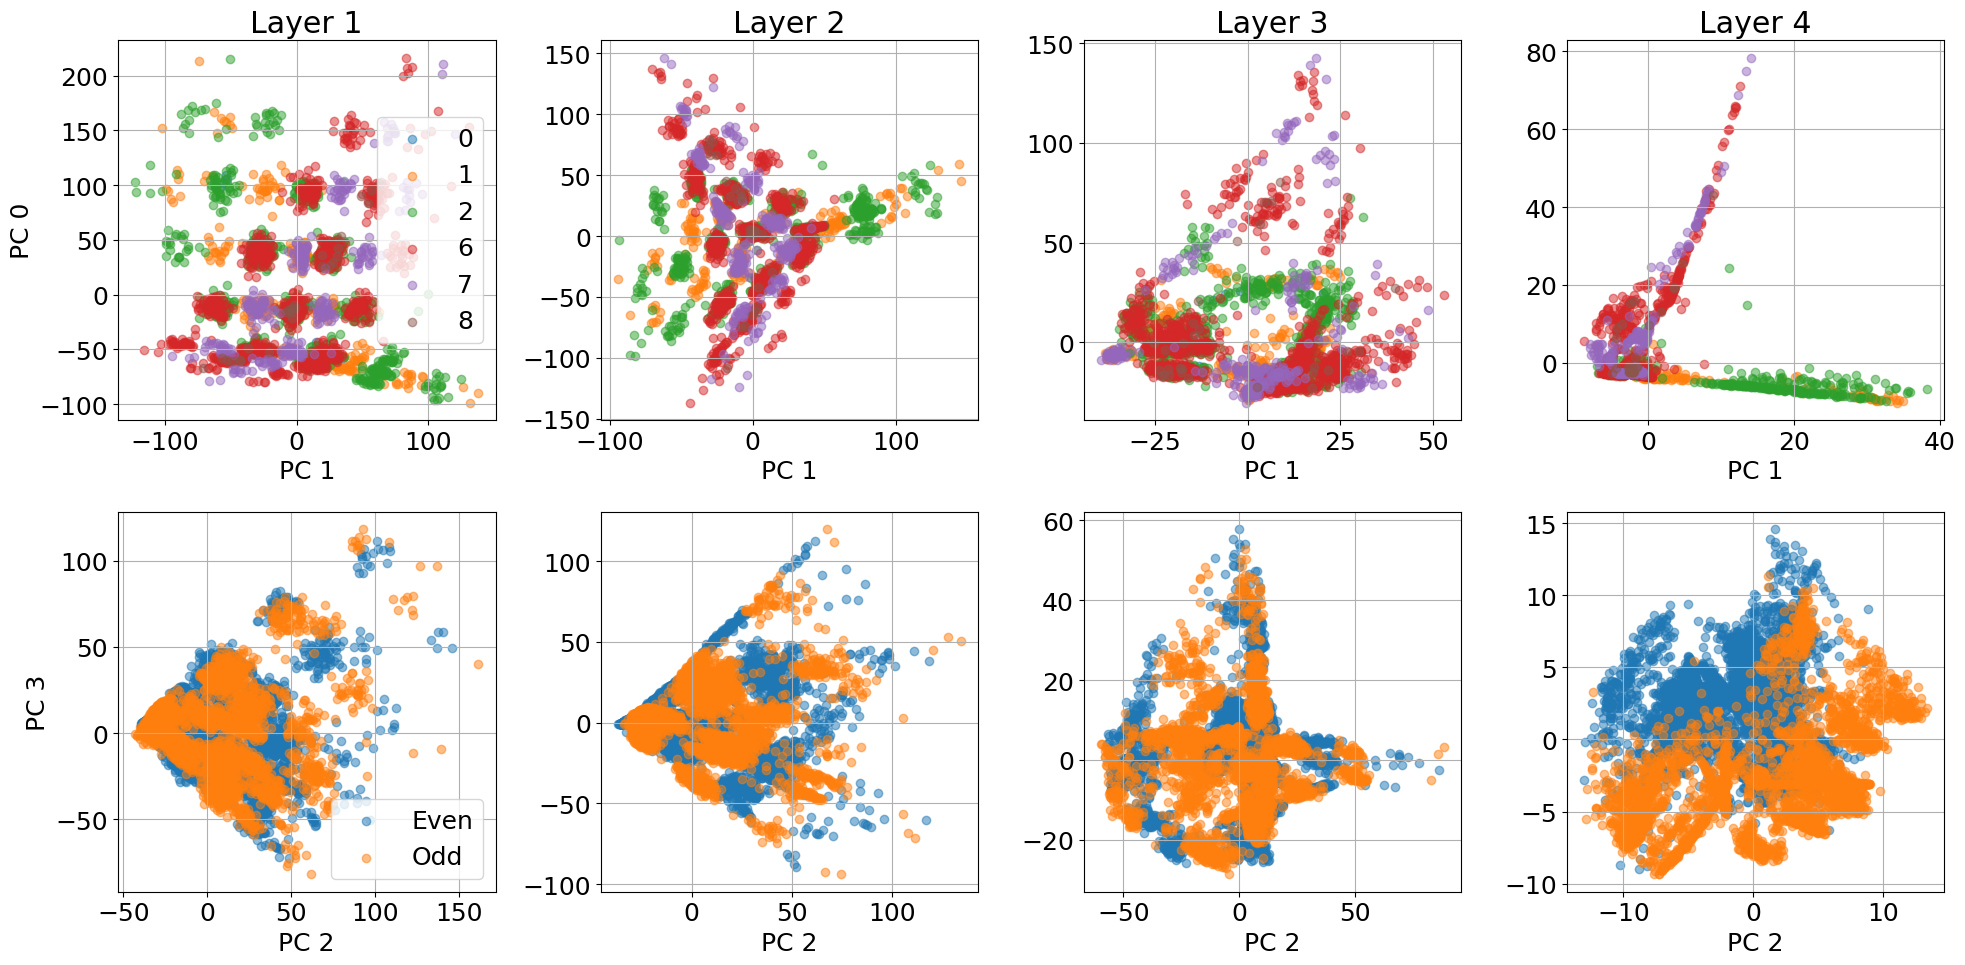

In [25]:

#reload_model(100)
epoch=200
reload_model(epoch)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 18
#reload_model(epoch)

plt.figure(figsize=(20, 10))
#plt.hspace()
for layer in [1,2,3, 4]:

    comp_n= 4
    new_pca = PCA(n_components=comp_n)
    #layer=1
    #imp_neurons = np.where(inf_score > np.mean(inf_score))[0]
    #new_s1_prof = new_pca.fit_transform(tmp[layer])
    new_s1_att = new_pca.fit_transform(tmp_att[layer])


    in1 = 2
    in2 = 3
    plt.subplot(2, 4, 4+ layer)
    
    plt.xlabel(f"PC {in1}")
    if layer == 1:
        plt.ylabel(f"PC {in2}")
    #plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
    for i in range(0, 2):
        on = np.where(dataset.attack_labels %2 == i)
        plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="Even" if i == 0 else "Odd", alpha=0.5)
        #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label="Even HW" if i == 0 else "Odd HW", alpha=0.5)
    plt.grid()
    if layer == 1:
        plt.legend(loc=0)
    #plt.legend(loc=1)

    #plt.savefig(f"even_odd_epoch_{epoch}.png", dpi=200)
    plt.subplot(2, 4,layer)
    in1 = 1
    in2 = 0
    plt.xlabel(f"PC {in1}")
    plt.title(f"Layer {layer}")
    if layer == 1:
        plt.ylabel(f"PC {in2}")
    for i in [0, 1, 2, 6, 7, 8]:
    #for i in range(9):
        on, = np.where(dataset.attack_labels == i)
        plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                    label=f"{i}", alpha=0.5)
    # plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 1], label="KMEANs")
    # #plt.scatter(initialize_arr[:, 2], initialize_arr[:, 1], label="INIT")
    # plt.plot(kmeans.cluster_centers_[sorted_points, 2], kmeans.cluster_centers_[sorted_points, 1])
    plt.grid()
    if layer == 1:
        plt.legend(loc=0)
    #plt.xlim([-1000, 0])
    #plt.savefig(f"even_odd_epoch_{epoch}.png", dpi=200)
plt.tight_layout()
plt.savefig("layer_evolution_ches_200.png", dpi=200)
plt.show()

In [29]:
out_logits=[]
import gc
gc.collect()
#reload_model(50)

comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])


for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"{i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()

plt.legend(loc=0)
plt.tight_layout()
plt.savefig("hi_lo_100_pcs.png", dpi=200)
plt.close()
reload_model(50)
comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
in1, in2 = 2, 1
for i in range(0, 2):
    on = np.where(dataset.attack_labels % 2 == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label="Even" if i == 0 else "Odd", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("even_odd_50_pcs.png", dpi=200)
plt.close()

313/313 [==============================] - 0s 1ms/step


1/1 [==============================] - 0s 15ms/step


152/152 [==============================] - 0s 2ms/step


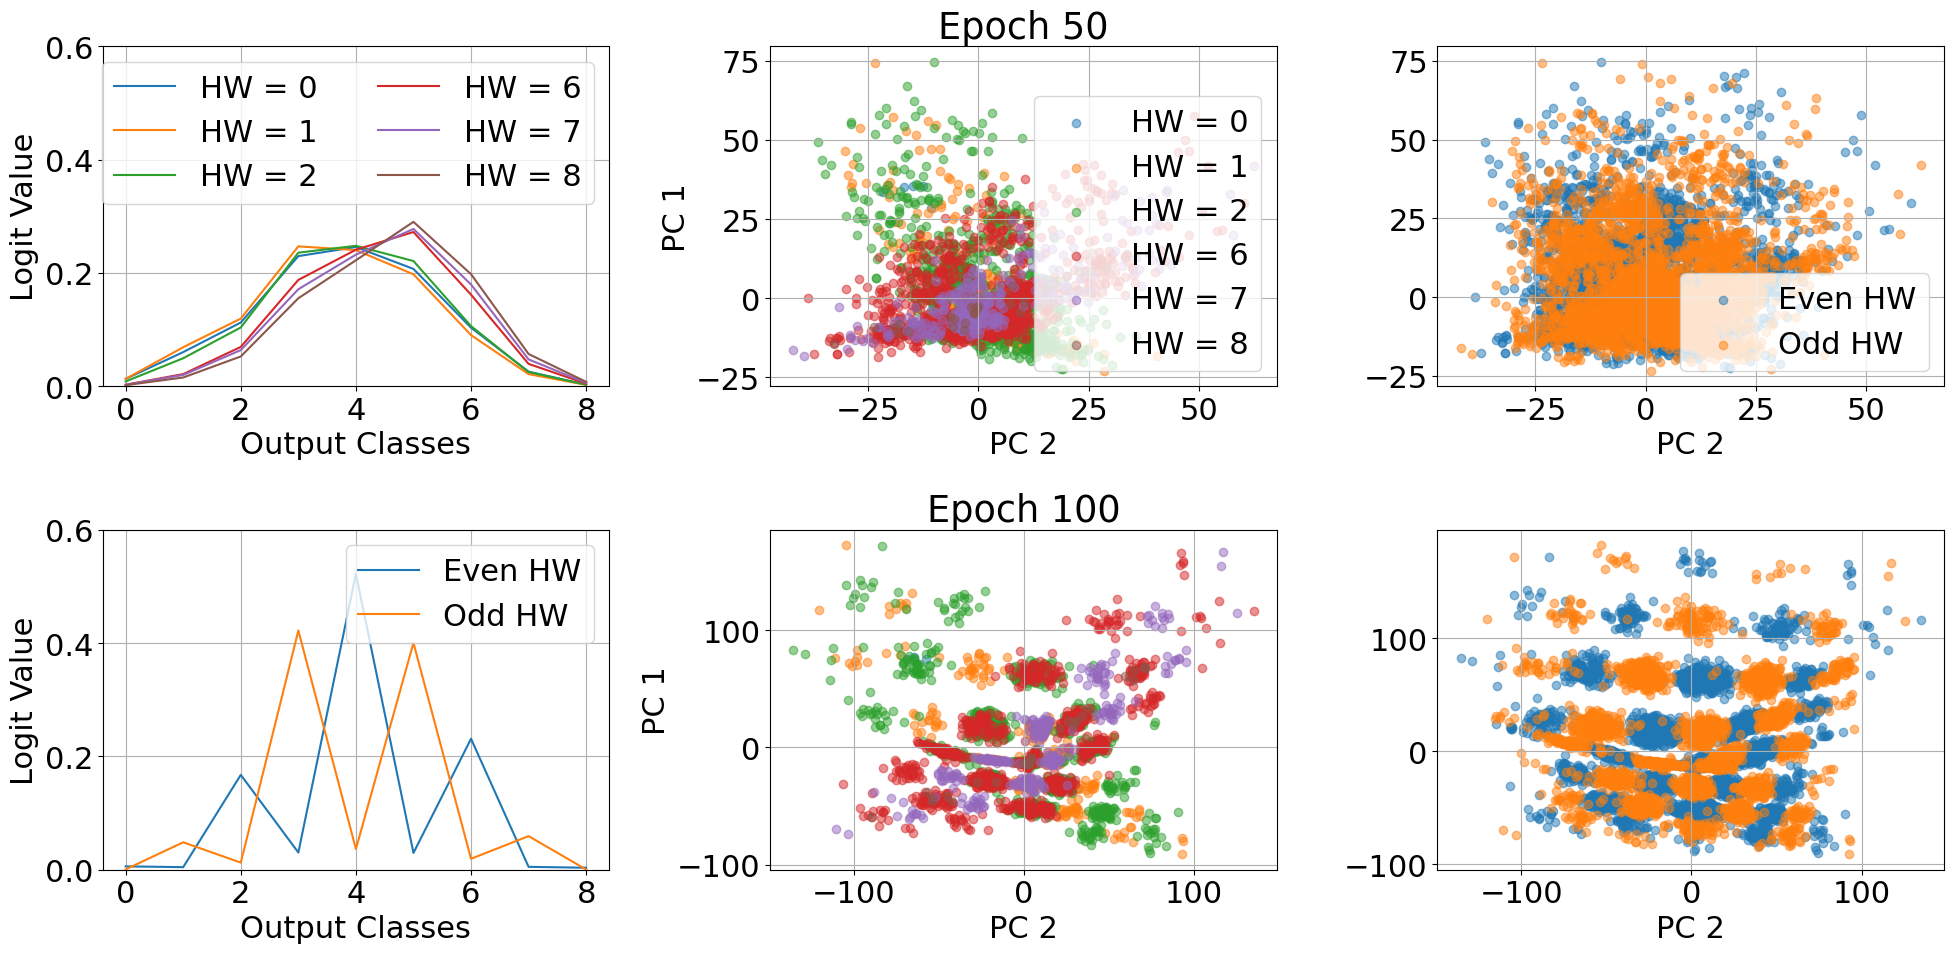

In [13]:
reload_model(50)
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^
                dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
font = {'size'   : 18}
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
#matplotlib.rc('font', **font)
# Prepare logits
out_logits = []
plt.figure(figsize=(20, 10))  # Adjust the figure size for 1x3 layout

# Subplot 1: Logits
plt.subplot(2, 3, 1)
for i in [0, 1, 2, 6, 7, 8]:
    indices, = np.where(dataset.attack_labels == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
plt.ylim([0, 0.6])
plt.grid()
plt.legend(loc=0,ncol=2)
#plt.title("Logits by HW")
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
# PCA preparation
comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])

# Subplot 2: PC scatter plot for PC2 vs PC1
plt.subplot(2, 3, 3)
in1, in2 = 2, 1
for i in range(0, 2):
    on = np.where(dataset.attack_labels % 2 == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label="Even HW" if i == 0 else "Odd HW", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.legend(loc=4)


# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 3, 2)
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.title("Epoch 50")
plt.grid()
plt.legend(loc=4)
#plt.title("PCA Scatter (PC1 vs PC0)")
reload_model(100)
plt.subplot(2, 3, 4)
for i in [0, 1]:
    indices, = np.where(dataset.attack_labels%2 == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"Even HW" if i == 0 else "Odd HW")
plt.ylim([0, 0.6])
plt.grid()
plt.legend(loc=1)
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")

# PCA preparation
comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])


# Subplot 2: PC scatter plot for PC2 vs PC1
plt.subplot(2, 3, 6)
in1, in2 = 2, 1
for i in range(0, 2):
    on = np.where(dataset.attack_labels % 2 == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label="Even HW" if i == 0 else "Odd HW", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()

#plt.legend(loc=4)

# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 3, 5)
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("Epoch 100")
#plt.legend(loc=4)

# Save or show the combined plot
plt.tight_layout()
#plt.savefig(f"combined_plots_ches_lowes.png", dpi=20)
 
plt.show()

In [12]:
copy_for_patch = new_s1_att.copy()

def repeat_product(x, y):
    return np.transpose([np.tile(x, len(y)), 
                            np.repeat(y, len(x))])

from sklearn.cluster import KMeans, SpectralClustering
kmeans_with_class_erbij = np.append(new_s1_att, ((dataset.attack_labels%2) *70).reshape(-1,1), axis=1)

init_arr_x = np.linspace(-100, 100, 7)
init_arr_y = np.linspace(160, -90, 7)

initialize_arr = repeat_product(init_arr_y, init_arr_x)
label_coords_for_init = np.zeros((len(initialize_arr), 1))
for i in range(len(initialize_arr)):
    label_coords_for_init[i] = ((i+1)%2)*70
initialize_arr_class = np.append(initialize_arr, label_coords_for_init, axis=1)
print(initialize_arr)
initialize_arr = np.append(np.zeros((len(initialize_arr), 1)), initialize_arr, axis=1)
initialize_arr_class = np.append(np.zeros((len(initialize_arr), 1)), initialize_arr_class, axis=1)
kmeans = KMeans(len(initialize_arr),init=initialize_arr_class)
kmeans.fit(kmeans_with_class_erbij[:])

kmeans.cluster_centers_

[[ 160.         -100.        ]
 [ 118.33333333 -100.        ]
 [  76.66666667 -100.        ]
 [  35.         -100.        ]
 [  -6.66666667 -100.        ]
 [ -48.33333333 -100.        ]
 [ -90.         -100.        ]
 [ 160.          -66.66666667]
 [ 118.33333333  -66.66666667]
 [  76.66666667  -66.66666667]
 [  35.          -66.66666667]
 [  -6.66666667  -66.66666667]
 [ -48.33333333  -66.66666667]
 [ -90.          -66.66666667]
 [ 160.          -33.33333333]
 [ 118.33333333  -33.33333333]
 [  76.66666667  -33.33333333]
 [  35.          -33.33333333]
 [  -6.66666667  -33.33333333]
 [ -48.33333333  -33.33333333]
 [ -90.          -33.33333333]
 [ 160.            0.        ]
 [ 118.33333333    0.        ]
 [  76.66666667    0.        ]
 [  35.            0.        ]
 [  -6.66666667    0.        ]
 [ -48.33333333    0.        ]
 [ -90.            0.        ]
 [ 160.           33.33333333]
 [ 118.33333333   33.33333333]
 [  76.66666667   33.33333333]
 [  35.           33.33333333]
 [  -6.6

array([[-4.46670265e+01,  1.72599075e+02, -1.04443787e+02,
         7.00000000e+01],
       [-5.67147223e+01,  7.78154411e+01, -1.16471324e+02,
         0.00000000e+00],
       [-5.63893705e+01,  7.55467430e+01, -8.86386238e+01,
         7.00000000e+01],
       [-5.88174794e+01,  2.61890003e+01, -8.67876308e+01,
        -7.10542736e-15],
       [-6.23682461e+01,  9.37157297e+00, -7.77875607e+01,
         7.00000000e+01],
       [-6.34834552e+01, -2.00761119e+01, -6.94781850e+01,
        -7.10542736e-15],
       [-5.23607319e+01, -4.92669529e+01, -6.91157702e+01,
         7.00000000e+01],
       [-5.10316794e+01,  1.33685020e+02, -9.07290099e+01,
        -7.10542736e-15],
       [-5.57233542e+01,  1.21615170e+02, -7.22925811e+01,
         7.00000000e+01],
       [-6.07085164e+01,  7.13505942e+01, -6.14670709e+01,
        -7.10542736e-15],
       [-6.11121257e+01,  2.16439657e+01, -5.54388489e+01,
         7.00000000e+01],
       [-6.35530793e+01, -3.11233135e+00, -4.60684736e+01,
      

In [202]:
clusters = kmeans.predict(kmeans_with_class_erbij)

def sort_points_indices(points, margin=0):
    """
    Return the indices of points sorted by x primarily and y within x margin.

    :param points: NumPy array of shape (n, 2), where each row is (x, y).
    :param margin: Float, margin within which x difference is ignored for ordering.
    :return: NumPy array of indices representing the sorted order.
    """
    # Sort primarily by x
    primary_sort_indices = np.argsort(points[:, 1], kind="mergesort")[::-1]
    sorted_points = points[primary_sort_indices]

    sorted_indices = []
    temp_group = [primary_sort_indices[0]]

    # Group and sort by y within x margin
    for i in range(1, len(sorted_points)):
        if np.min(np.abs(sorted_points[i, 1] - points[temp_group, 1])) <= margin:
            temp_group.append(primary_sort_indices[i])
        else:
            temp_group = np.array(temp_group)
            sorted_indices.extend(temp_group[np.argsort(points[temp_group, 0], kind="mergesort")])
            temp_group = [primary_sort_indices[i]]
    temp_group = np.array(temp_group)
    sorted_indices.extend(temp_group[np.argsort(points[temp_group, 0], kind="mergesort")])

    return np.array(sorted_indices)

margin = 5

sorted_points = sort_points_indices(kmeans.cluster_centers_[:, [2, 1]], margin)
print(kmeans.cluster_centers_[sorted_points])
when_swap_lower = []
sorted_cluster_centers = kmeans.cluster_centers_[sorted_points]
for i in range(1, 49):
    if sorted_cluster_centers[i-1, 2] > sorted_cluster_centers[i, 2]:
        when_swap_lower.append(i)
for i in range(49):
    print(i, len(np.where(clusters==sorted_points[i])[0]))
print(when_swap_lower)

[[-4.46670952e+01  1.72599167e+02 -1.04443756e+02  7.00000000e+01]
 [-4.66927858e+01  1.69950315e+02 -4.45708289e+01  7.00000000e+01]
 [-4.75935458e+01  1.66657203e+02  2.44846619e+00  0.00000000e+00]
 [-4.59984078e+01  1.58661562e+02  5.01921468e+01  7.00000000e+01]
 [-4.45669266e+01  1.57316821e+02  9.29278915e+01 -7.10542736e-15]
 [-4.74184399e+01  1.61214607e+02  1.16303783e+02  7.00000000e+01]
 [-5.10317369e+01  1.33685077e+02 -9.07289886e+01  0.00000000e+00]
 [-5.57234085e+01  1.21615210e+02 -7.22925623e+01  7.00000000e+01]
 [-5.53222379e+01  1.19525674e+02 -3.72743103e+01 -7.10542736e-15]
 [-5.43596453e+01  1.15479006e+02  2.16488864e+00  7.00000000e+01]
 [-5.17764912e+01  1.09671981e+02  5.09997650e+01 -7.10542736e-15]
 [-5.29106425e+01  1.09757602e+02  7.94536815e+01  7.00000000e+01]
 [-5.40996162e+01  1.06731059e+02  1.08843567e+02 -7.10542736e-15]
 [-5.67147535e+01  7.78155053e+01 -1.16471320e+02  0.00000000e+00]
 [-5.63894021e+01  7.55467897e+01 -8.86386159e+01  7.00000000e

In [203]:
count = 0
hw_for_cluster_s1 = np.zeros(49)
for i in range(49):
    
    if i in when_swap_lower and count <7:
        count +=1
    hw_for_cluster_s1[sorted_points[i]] = count

count = 7-when_swap_lower[0]
when_lower_count=0
new_hw_values_s1 = hw_for_cluster_s1[clusters] 
hw_for_cluster_s2 = np.zeros(49)
for i in range(49):
    
    count +=1
    if i in when_swap_lower and when_lower_count+1 < len(when_swap_lower):
        diff_here = when_swap_lower[when_lower_count+1] -when_swap_lower[when_lower_count]
        print()
        if diff_here > 6:
            
            count = max(0, 7 -diff_here)
        else:
            diff_here = when_swap_lower[when_lower_count+1] -when_swap_lower[when_lower_count-1]
            count = max(0, 8 -diff_here)
        when_lower_count +=1
    hw_for_cluster_s2[sorted_points[i]] = count
new_hw_values_s2 = hw_for_cluster_s2[clusters] 

In [34]:
reload_model(100)
comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
new_model_for_probe = Model(model.layers[layer+1].input, model.output)
copy_for_patch = new_s1_att.copy()
copy_for_patch[:, 1] = 140
copy_for_patch[:, 0] = -20

hw_prior = np.zeros(9)
for i in range(256):
    hw_prior[hw(i)] += 1
#hw_prior[4] += 200
print(hw_prior)
hw_prior/=256

predicts = new_model_for_probe.predict(new_pca.inverse_transform(copy_for_patch))
prior = np.mean(predicts, axis=0)
low_hw_s1 = np.sum(predicts[:, 0:4], axis=1)
high_hw_s1 = np.sum(predicts[:, 5:9], axis=1)

even_hw_s1 = np.sum(predicts[:, [0,2,4,6,8]], axis=1)
odd_hw_s1 = np.sum(predicts[:, [1,3,5,7]], axis=1)

even_low_hw_s1 = np.sum(predicts[:, [0,2]], axis=1)
odd_low_hw_s1 = np.sum(predicts[:, [1,3]], axis=1)

even_high_hw_s1 = np.sum(predicts[:, [6,8]], axis=1)
odd_high_hw_s1 = np.sum(predicts[:, [5,7]], axis=1)
list_of_indices_s1 = [] 
for i in range(9):
    list_of_indices_s1.append(np.argsort(predicts[:, i])[::-1][:int(10000*hw_prior[i])])
hw_values_s1 = np.argmax(predicts, axis=1)
#hw_values_s1 = np.argmax(predicts, axis=1)
hw_normalized_values_s1 = np.argmax(predicts/hw_prior, axis=1)


copy_for_patch = new_s1_att.copy()

copy_for_patch[:, 2] = -130
copy_for_patch[:, 0] = -20


predicts = new_model_for_probe.predict(new_pca.inverse_transform(copy_for_patch))

low_hw_s2 = np.sum(predicts[:, 0:4], axis=1)
high_hw_s2= np.sum(predicts[:, 5:9], axis=1)

even_hw_s2 = np.sum(predicts[:, [2,4,6]], axis=1)
odd_hw_s2 = np.sum(predicts[:, [3,5]], axis=1)

even_low_hw_s2 = np.sum(predicts[:, [0,2]], axis=1)
odd_low_hw_s2 = np.sum(predicts[:, [1,3]], axis=1)

even_high_hw_s2 = np.sum(predicts[:, [6,8]], axis=1)
odd_high_hw_s2 = np.sum(predicts[:, [5,7]], axis=1)
list_of_indices_s2 = [] 
for i in range(9):
    list_of_indices_s2.append(np.argsort(predicts[:, i])[::-1][:int(10000*hw_prior[i])])
hw_values_s2 = np.argmax(predicts, axis=1)
prior = np.mean(predicts, axis=0)
hw_normalized_values_s2 = np.argmax(predicts/hw_prior, axis=1)
hw_values_s2_with_new_stuff= np.zeros(hw_values_s2.shape) -1
hw_values_s1_with_new_stuff= np.zeros(hw_values_s2.shape) -1
for i in range(9):
    hw_values_s2_with_new_stuff[list_of_indices_s2[i]] = i
    hw_values_s1_with_new_stuff[list_of_indices_s1[i]] = i


313/313 [==============================] - 0s 1ms/step
[ 1.  8. 28. 56. 70. 56. 28.  8.  1.]
313/313 [==============================] - 0s 1ms/step


In [35]:
# diff_s1 = high_hw_s1 - low_hw_s1
# diff_s2 = high_hw_s2- low_hw_s2

# even_s1 = even_hw_s1 - odd_hw_s1
# even_s2 = even_hw_s2 - odd_hw_s2

# diff_even_s1 = even_high_hw_s1 - even_low_hw_s1
# diff_even_s2 = even_high_hw_s2 - even_low_hw_s2

# diff_odd_s1 = odd_high_hw_s1 - odd_low_hw_s1
# diff_odd_s2 = odd_high_hw_s2 - odd_low_hw_s2

# final_hw_values_s1 = np.zeros(len(dataset.x_attack))
# final_hw_values_s2 = np.zeros(len(dataset.x_attack))

# even_indices_s1 = np.where(even_s1> 0)[0]
# even_indices_s2 = np.where(even_s2> 0)[0]
# odd_indices_s1 = np.where(even_s1<= 0)[0]
# odd_indices_s2 = np.where(even_s2<= 0)[0]


# even_indices_s1 = np.argsort(even_s1)[:len(dataset.x_attack)//2]
# even_indices_s2 = np.argsort(even_s2)[:len(dataset.x_attack)//2]
# odd_indices_s1 = np.argsort(even_s1)[len(dataset.x_attack)//2:]
# odd_indices_s2 = np.argsort(even_s2)[len(dataset.x_attack)//2:]

# argsort_s1_even = np.argsort(diff_even_s1[even_indices_s1]).astype(int)
# argsort_s2_even = np.argsort(diff_even_s2[even_indices_s2]).astype(int)
# argsort_s1_odd = np.argsort(diff_odd_s1[odd_indices_s1]).astype(int)
# argsort_s2_odd = np.argsort(diff_odd_s2[odd_indices_s2]).astype(int)
# hw_prior = np.zeros(9)
# for i in range(256):
#     hw_prior[hw(i)] += 1
# print(hw_prior)
# hw_prior/=256
# print(hw_prior)
# start_index = 0
# for i in range(9):
#     if i %2 ==1:
#         continue
#     num_vals = int(len(dataset.x_attack)//(1/hw_prior[i]))
#     if i == 4:
#         num_vals +=4
#     print(num_vals)
#     final_hw_values_s1[even_indices_s1[argsort_s1_even[start_index:start_index+num_vals]]] = i
#     final_hw_values_s2[even_indices_s2[argsort_s1_even[start_index:start_index+num_vals]]] = i
#     start_index += num_vals
# print(len(even_indices_s1), len(odd_indices_s1))
# start_index = 0
# for i in range(9):
#     if i %2 ==0:
#         continue
#     num_vals = int(len(dataset.x_attack)//(1/hw_prior[i]))
#     if i == 4:
#         num_vals +=4
#     print(num_vals)
#     final_hw_values_s1[odd_indices_s1[argsort_s1_odd[start_index:start_index+num_vals]]] = i
#     final_hw_values_s2[odd_indices_s2[argsort_s2_odd[start_index:start_index+num_vals]]] = i
#     start_index += num_vals

diff_s1 = high_hw_s1 - low_hw_s1
diff_s2 = high_hw_s2- low_hw_s2

final_hw_values_s1 = np.zeros(len(dataset.x_attack))
final_hw_values_s2 = np.zeros(len(dataset.x_attack))

argsort_s1 = np.argsort(diff_s1).astype(int)
argsort_s2 = np.argsort(diff_s2).astype(int)
hw_prior = np.zeros(9)
for i in range(256):
    hw_prior[hw(i)] += 1
hw_prior/=256
start_index = 0
for i in range(9):
    num_vals = int(len(dataset.x_attack)//(1/hw_prior[i]))
    if i == 4:
        num_vals +=4
    print(num_vals)
    final_hw_values_s1[argsort_s1[start_index:start_index+num_vals]] = i
    final_hw_values_s2[argsort_s2[start_index:start_index+num_vals]] = i
    start_index += num_vals
print(start_index)

39
312
1093
2187
2738
2187
1093
312
39
10000


0 39
1 312
2 1093
3 2187
4 2738
5 2187
6 1093
7 312
8 39


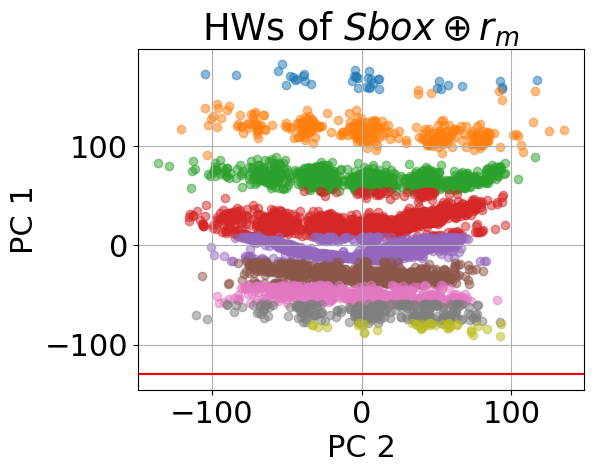

In [36]:
in1 = 2
in2 = 1
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
#plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
for i in range(0, 9):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s2==i)[0]
     print(i, len(on))
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
# for i in range(6, 9):
# #     if i %2 == 0:
# #           continue
#      on = np.where(hw_values_s1==i)
#      plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
#plt.axline(x = 140, color = 'r', label = 'Patched Value')
plt.axhline(y = -130, color = 'r', label = 'Patched Value')
#plt.legend(loc=4)
plt.tight_layout()
plt.title("HWs of $Sbox \oplus r_m$")
plt.grid()

#plt.legend(loc=4)
plt.savefig("sbox_r_m_with_red_line.png", dpi=200)

0 39
1 312
2 1093
3 2187
4 2738
5 2187
6 1093
7 312
8 39
0 39
1 312
2 1093
3 2187
4 2738
5 2187
6 1093
7 312
8 39


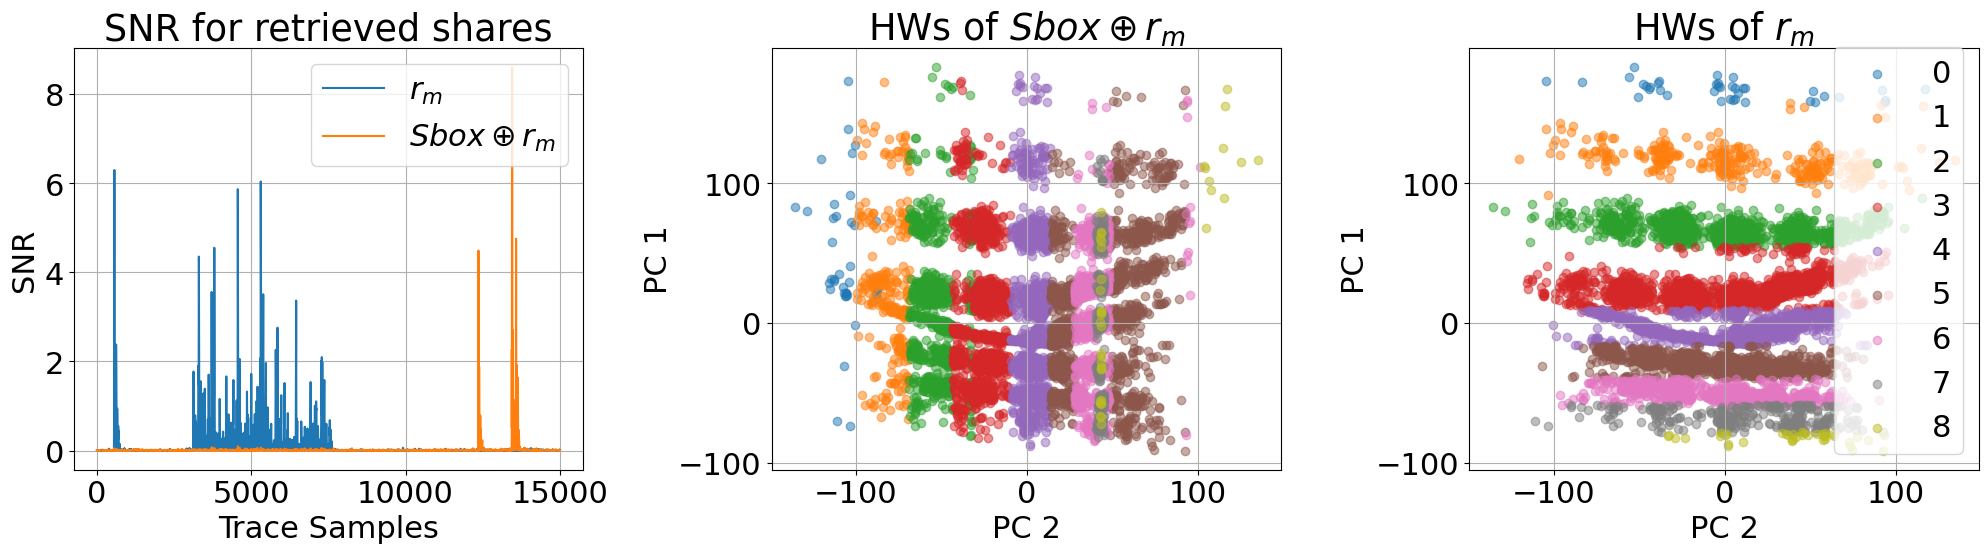

In [20]:
plt.figure(figsize=(20, 6))  # Adjust the figure size for 1x3 layout

# Subplot 1: Logits
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
plt.subplot(1, 3, 3)
in1 = 2
in2 = 1
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
#plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
for i in range(0, 9):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s2==i)[0]
     print(i, len(on))
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"{i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
# for i in range(6, 9):
# #     if i %2 == 0:
# #           continue
#      on = np.where(hw_values_s1==i)
#      plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
plt.title("HWs of $r_m$")
plt.grid()

plt.legend(loc=4)

in1 = 2
in2 = 1
plt.subplot(1,3,2)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.title("HWs of $Sbox \oplus r_m$")
#plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
for i in range(0, 9):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s1==i)[0]
     print(i, len(on))
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"{i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
# for i in range(6, 9):
# #     if i %2 == 0:
# #           continue
#      on = np.where(hw_values_s1==i)
#      plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
plt.grid()
#plt.legend()

plt.subplot(1,3,1)
plt.plot(snr_fast(dataset.x_attack, final_hw_values_s2), label="$r_m$")
plt.plot(snr_fast(dataset.x_attack, final_hw_values_s1), label="$Sbox \oplus r_m$")
plt.title("SNR for retrieved shares")
plt.xlabel("Trace Samples")
plt.legend(loc=1)
plt.grid()
plt.tight_layout()
plt.ylabel("SNR")
plt.savefig("Combined_patch_ches_lowest_res.png", dpi=20)
plt.savefig("Combined_patch_ches_lower_res.png", dpi=100)
plt.savefig("Combined_patch_ches.png", dpi=200)
plt.show()

 54/938 [>.............................] - ETA: 1s

2025-01-25 09:11:30.622008: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


313/313 [==============================] - 0s 1ms/step
36
2/2 [==============================] - 0s 2ms/step
280
9/9 [==============================] - 0s 1ms/step
1116
35/35 [==============================] - 0s 1ms/step
1147
36/36 [==============================] - 0s 1ms/step
310
10/10 [==============================] - 0s 1ms/step
29
1/1 [==============================] - 0s 11ms/step
[array([0.0150052 , 0.00876426, 0.21962114, 0.04514345, 0.49881983,
       0.03654032, 0.16857465, 0.0038507 , 0.00368048], dtype=float32), array([1.3331363e-03, 7.6799288e-02, 2.7240125e-02, 4.8185250e-01,
       4.1687552e-02, 3.1616750e-01, 1.1582933e-02, 4.3107133e-02,
       2.2981904e-04], dtype=float32), array([0.00839215, 0.0084745 , 0.20551658, 0.04069606, 0.51827216,
       0.02389513, 0.1881303 , 0.00342653, 0.00319678], dtype=float32), array([0.00344872, 0.00214179, 0.13615288, 0.0213373 , 0.504902  ,
       0.03018591, 0.29082346, 0.00687992, 0.00412795], dtype=float32), array([2.4239246e

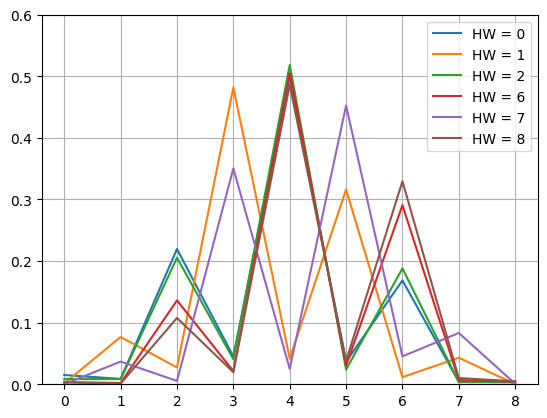

In [8]:
out_logits = []
epoch=100
reload_model(epoch)
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))

for i in [0,1,2, 6,7,8]:
    indices, =np.where((dataset.attack_labels == i))
    #indices_other, = np.where(sbox_ins_att  % 4 == (i >>2) %4)
    #final_indices = np.intersect1d(indices, indices_other)
    print(len(indices))
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
    plt.ylim([0, 0.6])
    #

    #plt.savefig(f"logits_{i}_epoch_{epoch}.png", dpi=400)
    #plt.show()
plt.grid()
plt.legend()
plt.savefig(f"logits_epoch_{epoch}.png", dpi=400)
print(out_logits)


In [32]:
from scipy.stats import spearmanr
array_corr = []
for i in range(dataset.x_attack.shape[1]):
    array_corr.append( spearmanr(dataset.x_attack[:, i], new_s1_att[:,2], axis=1).correlation)


from scipy.stats import spearmanr
array_corr_other = []
for i in range(dataset.x_attack.shape[1]):
    array_corr_other.append( spearmanr(dataset.x_attack[:, i], new_s1_att[:,0], axis=1).correlation)



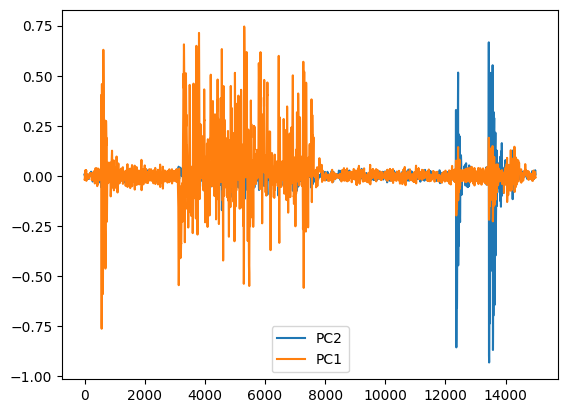

In [33]:
plt.plot(array_corr, label="PC2")
plt.plot(array_corr_other, label="PC1")
plt.legend()
plt.show()

In [1]:
import numpy as np
def bmatrix(a):
    """Returns a LaTeX bmatrix

    :a: numpy array
    :returns: LaTeX bmatrix as a string
    """
    sum= np.sum(a)    
    if len(a.shape) > 2:
        raise ValueError('bmatrix can at most display two dimensions')
    lines = str(a).replace('[', '').replace(']', '').splitlines()
    rv = [r'\begin{bmatrix}']
    rv += ['\\vphantom\{1111\}  ' + ' & \\vphantom\{1111\}'.join(l.split()) + r'\\' for l in lines]
    rv +=  [r'\end{bmatrix}']
    return '\n'.join(rv)

matrix_but_more_d = np.zeros((9, 9, 9))
for i in range(256):
    for j in range(256):

        matrix_but_more_d[hw(i), hw(j), hw(j^i)] += 1

for i in range(9):
    print(f"---------------------------{i}-----------------------------")
    print(bmatrix(matrix_but_more_d[i]))

NameError: name 'hw' is not defined